Connected to Python 3.9.6

Connected to base (Python 3.12.7)

In [1]:
import os
import scanpy as sc
from utils import compute_nn
import pandas as pd
import numpy as np
import pickle
import random
random.seed(2025)
import sys
sys.path.append('/Users/zhaoyimin/Desktop/SCOPE Manuscipt')
from branchpoint_localization import trace_to_highest_density_point
os.chdir('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure4 Seacell Palantir/Seacell')

### prepare the data

In [2]:
# Load data and conformal results
data = sc.read_h5ad('./iter100_alpha0.99_omit0.05_trees10/data_complete_results.h5ad')
with open('./iter100_alpha0.99_omit0.05_trees10/conformal_result.pkl', 'rb') as f:
    conformal_result = pickle.load(f)

data

AnnData object with n_obs × n_vars = 6386 × 12464
    obs: 'leiden', 'celltype', 'palantir_pseudotime', 'palantir_entropy', 'terminal_state_cluster', 'visit', 'iteration_recruited'
    var: 'highly_variable'
    uns: 'DM_EigenValues', 'celltype_colors', 'log1p', 'palantir_waypoints', 'pca'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_pca', 'X_umap', 'dummy_label', 'imputed_hvg', 'palantir_fate_probabilities', 'vae_latent_space'
    varm: 'PCs', 'feature_importance_hvg_iter_0', 'feature_importance_hvg_iter_1', 'feature_importance_hvg_iter_10', 'feature_importance_hvg_iter_11', 'feature_importance_hvg_iter_12', 'feature_importance_hvg_iter_13', 'feature_importance_hvg_iter_14', 'feature_importance_hvg_iter_15', 'feature_importance_hvg_iter_16', 'feature_importance_hvg_iter_17', 'feature_importance_hvg_iter_18', 'feature_importance_hvg_iter_19', 'feature_importance_hvg_iter_2', 'feature_importance_hvg_iter_20', 'feature_importance_hvg_iter_21', 'feature_importance_hvg_it

In [3]:
#load in mellon data
mellon_data = sc.read_h5ad('/Users/zhaoyimin/Desktop/seacell branchpoint/seacell_multiome_palantir_withoutCLP_mellon.h5ad')
data.obs['mellon_log_density'] = mellon_data[data.obs_names].obs['mellon_log_density']
data.obs['mellon_log_density_clipped'] = mellon_data[data.obs_names].obs['mellon_log_density_clipped']
#data.write_h5ad('./iter100_alpha0.99_omit0.05_trees10/data_complete_results_allinfo.h5ad')

In [4]:
pseudo_time_ranks = np.argsort(data.obs['palantir_pseudotime'][data.obs['terminal_state_cluster'] == 'TBD'].values)
pseudo_time_ranks = pseudo_time_ranks[::-1]
cells2recruit_barcode = data[data.obs['terminal_state_cluster'] == 'TBD'][pseudo_time_ranks,:].obs_names
data_subset = data[cells2recruit_barcode]

# Get prediction sets from conformal results
prediction_set = conformal_result['prediction_set'].copy()

# Define conditions for different prediction set combinations
conditions = [
    prediction_set['prediction_set'].apply(lambda x: x == {'Ery'}),
    prediction_set['prediction_set'].apply(lambda x: x == {'Mono'}),
    prediction_set['prediction_set'].apply(lambda x: x == {'Ery', 'Mono'})
]

### 1. plot cells with prediction set {Mono} {Ery} {Mono, Ery}

([], [])

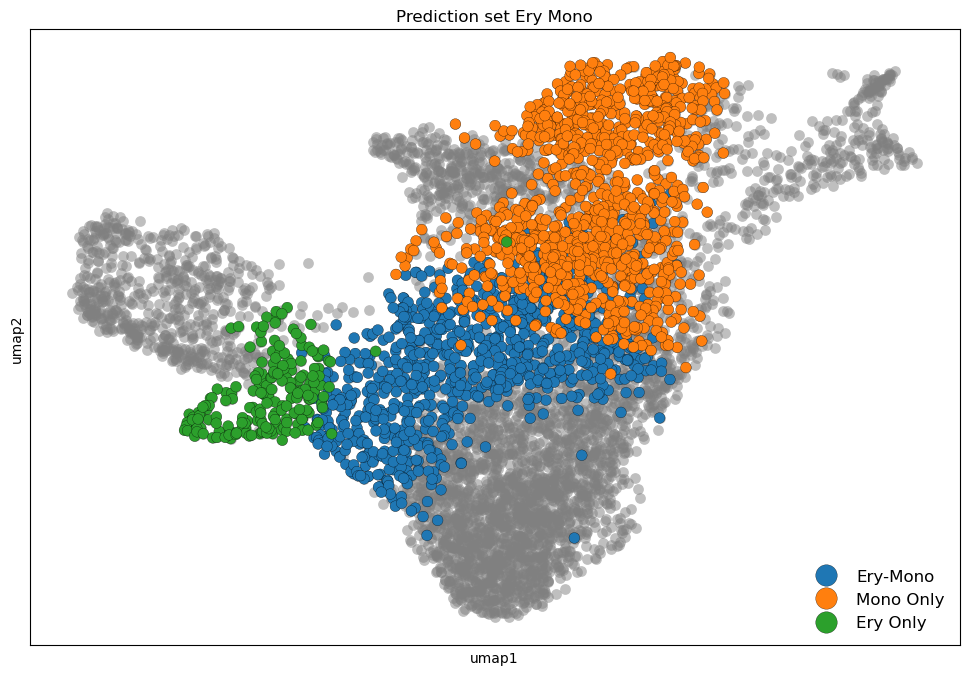

In [5]:
barcode_ery = prediction_set[conditions[0]].index
barcode_mono = prediction_set[conditions[1]].index
barcode_ery_mono = prediction_set[conditions[2]].index

combined_barcode = barcode_ery_mono.append(barcode_mono).append(barcode_ery)

df = pd.DataFrame({'umap1': data.obsm['X_umap'][:, 0], 'umap2': data.obsm['X_umap'][:, 1], 'Labels':data.obs['terminal_state_cluster'].tolist()})
df.index = data.obs_names
df.loc[cells2recruit_barcode, 'Labels'] = 'TBD'
df.loc[barcode_ery, 'Labels'] = 'Ery Only'
df.loc[barcode_mono, 'Labels'] = 'Mono Only'
df.loc[barcode_ery_mono, 'Labels'] = 'Ery-Mono'

#plot branchpoint in umap embedding
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.figure(figsize=(12, 8))

# Plot all points in light grey as a base
sns.scatterplot(
    x='umap1', y='umap2', data=df,
    color='grey', edgecolor=None
    , s=60, linewidth=0,legend=False, alpha = 0.5
    )

# Plot special label = 1 in red (highlighted fate)
df_highlight = df.loc[combined_barcode]
sns.scatterplot(
    x='umap1', y='umap2', data=df_highlight,
    edgecolor='black', linewidth=0.2, s=60, hue='Labels',  # Different color for each class
     palette='tab10'
)

# Clean up and finalize
plt.legend(loc='lower right', markerscale=2.0,  fontsize=12, frameon=False)
plt.title('Prediction set Ery Mono')
plt.xlabel('umap1')
plt.ylabel('umap2')
plt.xticks([])
plt.yticks([])

### 2. do density clustering and get branchpoint

In [6]:
# Combine with OR
combined_condition = conditions[0] | conditions[1] | conditions[2]

# Filter the DataFrame
barcode_mono_ery = prediction_set[combined_condition].index

#subset dataset
data_subset_mono_ery = data[barcode_mono_ery]

#calculate KNN graph
distance, indices = compute_nn(data_subset_mono_ery.obsm['X_pca'], 30)

#do density clustering in new KNN graph
density = data_subset_mono_ery.obs['mellon_log_density'].to_list()


# Step 1: Create label list and index mapping
unique_labels = ['Mono', 'Ery']
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
n_labels = len(unique_labels)
n_cells = data_subset_mono_ery.n_obs

# Step 2: Convert prediction_set to binary label matrix
label_matrix = np.zeros((n_cells, n_labels), dtype=bool)
for i, label_set in enumerate(prediction_set.loc[barcode_mono_ery]['prediction_set']):
    for label in label_set:
        if label in label_to_idx:
            label_matrix[i, label_to_idx[label]] = True

# Step 3: Efficiently filter KNN graph
filtered_indices = []
filtered_distances = []

for i in range(n_cells):
    i_vec = label_matrix[i]  # shape: (n_labels,)
    neighbor_idxs = indices[i]  # original neighbors (shape: (k,))
    
    neighbor_vecs = label_matrix[neighbor_idxs]  # shape: (k, n_labels)
    
    # Subset condition: i's label vector <= neighbor's label vector
    valid_mask = np.all(i_vec <= neighbor_vecs, axis=1)

    # Apply mask
    filtered_indices.append(neighbor_idxs[valid_mask])
    filtered_distances.append(distance[i][valid_mask])


clusters = {}

#for each cell, determine the cluster center 
for i in range(data_subset_mono_ery.obsm['X_pca'].shape[0]):
    #if i not in visited:
    center = trace_to_highest_density_point(i, filtered_indices, density)
    if center in clusters:
        clusters[center].append(i)
    else:
        clusters[center] = [i]


center_most_mono_ery = np.nan
most_mono_ery  = 0
for center, points in clusters.items():
    barcode = barcode_mono_ery[points]
    # Count cells with both Mono and Ery in prediction set
    num_mono_ery = 0
    for bc in barcode:
        if bc in prediction_set.index:
            pred_set = prediction_set.loc[bc, 'prediction_set']
            if 'Mono' in pred_set and 'Ery' in pred_set:
                num_mono_ery += 1

    if num_mono_ery > most_mono_ery:
        most_mono_ery = num_mono_ery
        center_most_mono_ery = center

barcode_branchpoint = barcode_mono_ery[clusters[center_most_mono_ery]]

### plot the branchpoint in umap embedding 

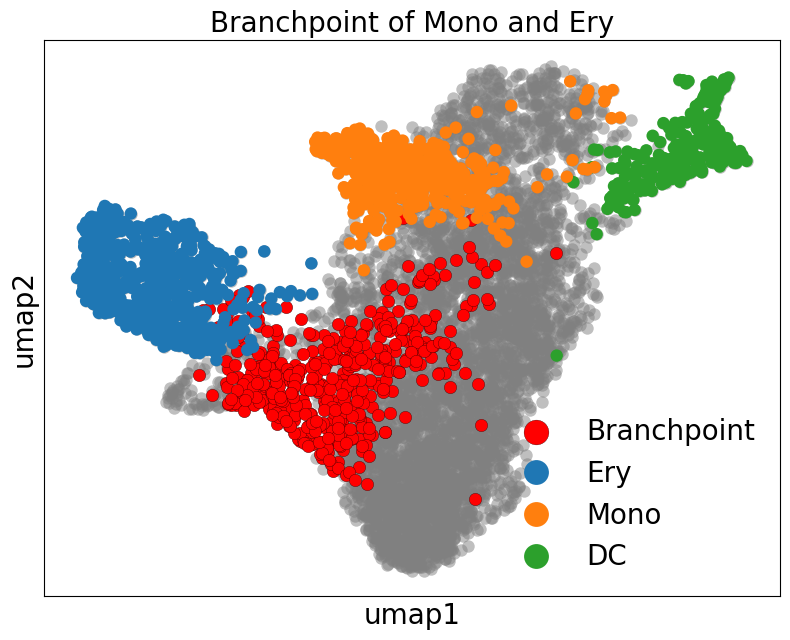

In [7]:
df = pd.DataFrame({'umap1': data.obsm['X_umap'][:, 0], 'umap2': data.obsm['X_umap'][:, 1], 'Labels':data.obs['terminal_state_cluster'].tolist()})
df.index = data.obs_names
df.loc[cells2recruit_barcode, 'Labels'] = 'TBD'
df.loc[barcode_branchpoint, 'Labels'] = 'Branchpoint'


#plot branchpoint in umap embedding
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

#plt.figure(figsize=(12, 8))
#plt.figure(figsize=(8, 6))
plt.figure(figsize=(8, 6.5))


# Plot all points in light grey as a base
sns.scatterplot(
    x='umap1', y='umap2', data=df,
    color='grey', edgecolor=None, s=80, linewidth=0, alpha=0.5, legend=False
    )

# Plot special label = 1 in red (highlighted fate)
df_highlight = df[df['Labels'] == 'Branchpoint']
sns.scatterplot(
    x='umap1', y='umap2', data=df_highlight,
    color='red', edgecolor='black', linewidth=0.2, s=80, label='Branchpoint'
)

# Optionally: plot other label values (e.g., cell types) using `hue`
df_other = df[~df.index.isin(cells2recruit_barcode)]
if not df_other.empty:
    sns.scatterplot(
        x='umap1', y='umap2', data=df_other,
        hue='Labels', palette='tab10', s=80, linewidth=0, alpha=1, legend='brief'
    )

# Clean up and finalize
plt.legend(loc='lower right', markerscale=2.0,  fontsize=20, frameon=False)
plt.title('Branchpoint of Mono and Ery', fontsize=20)
plt.xlabel('umap1', fontsize=20)
plt.ylabel('umap2', fontsize=20)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
#plt.savefig('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure4 Seacell Palantir/Palantir/vector plot/branchpoint_mono_ery.pdf')

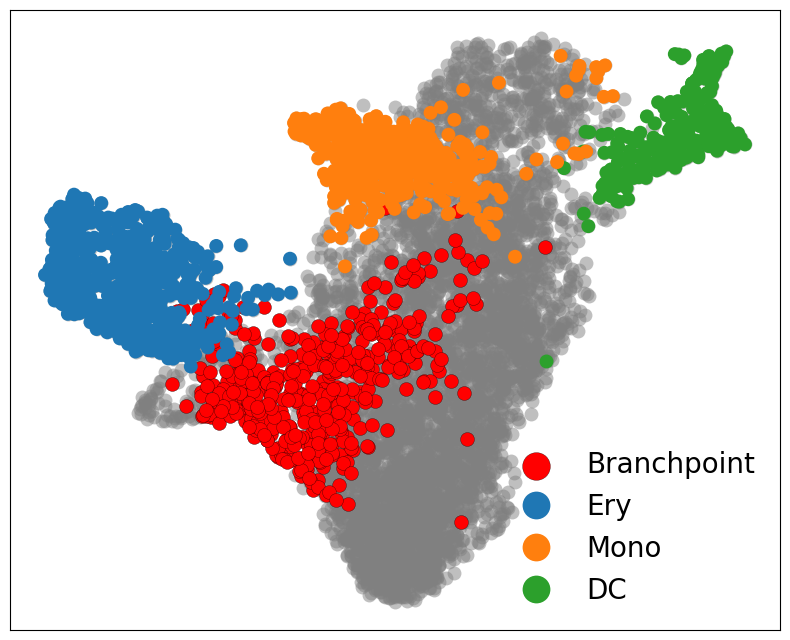

In [7]:
df = pd.DataFrame({'umap1': data.obsm['X_umap'][:, 0], 'umap2': data.obsm['X_umap'][:, 1], 'Labels':data.obs['terminal_state_cluster'].tolist()})
df.index = data.obs_names
df.loc[cells2recruit_barcode, 'Labels'] = 'TBD'
df.loc[barcode_branchpoint, 'Labels'] = 'Branchpoint'


#plot branchpoint in umap embedding
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

#plt.figure(figsize=(12, 8))
plt.figure(figsize=(8, 6.5))

# Plot all points in light grey as a base
sns.scatterplot(
    x='umap1', y='umap2', data=df,
    color='grey', edgecolor=None, s=100, linewidth=0, alpha=0.5, legend=False
    )

# Plot special label = 1 in red (highlighted fate)
df_highlight = df[df['Labels'] == 'Branchpoint']
sns.scatterplot(
    x='umap1', y='umap2', data=df_highlight,
    color='red', edgecolor='black', linewidth=0.2, s=100, label='Branchpoint'
)

# Optionally: plot other label values (e.g., cell types) using `hue`
df_other = df[~df.index.isin(cells2recruit_barcode)]
if not df_other.empty:
    sns.scatterplot(
        x='umap1', y='umap2', data=df_other,
        hue='Labels', palette='tab10', s=100, linewidth=0, alpha=1, legend='brief'
    )

# Clean up and finalize
plt.legend(loc='lower right', markerscale=2.0,  fontsize=20, frameon=False)
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure4 Seacell Palantir/Seacell/vector plot/branchpoint_mono_ery.pdf')


#### save the branchpoint data

In [8]:
data_mono_ery_branchpoint = data[barcode_branchpoint]
data_mono_ery_branchpoint.write_h5ad('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure4 Seacell Palantir/tradeseq new/seacell_data_mono_ery_branchpoint.h5ad')

### 3. subsample dataset for 500 trials and derive the p value

Coefficient (slope): -2.4222
Intercept: 0.9141


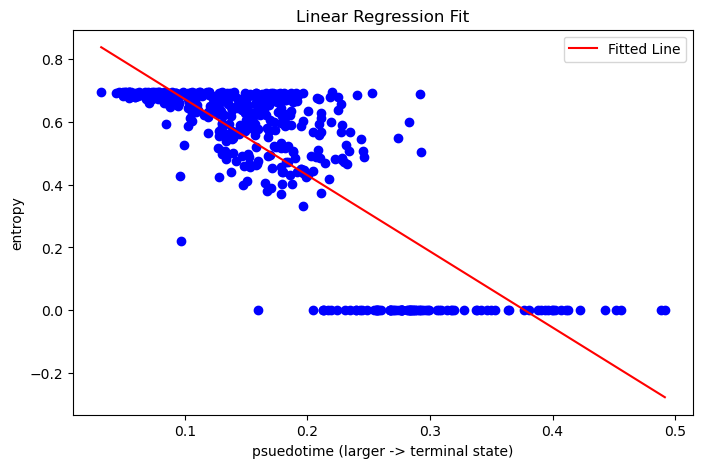

In [8]:
from scipy.stats import entropy
data_branchpoint = data[barcode_branchpoint]

branchpoint_pseudotime = data_branchpoint.obs['palantir_pseudotime']
branchpoint_fate_bias = data_branchpoint.obsm['dummy_label']
branchpoint_entropy = branchpoint_fate_bias.apply(lambda x: entropy(x), axis=1)

df_pseudotime_entropy = pd.DataFrame({'pseudotime':branchpoint_pseudotime, 'entropy': branchpoint_entropy})


#pseudotime 1 will be terminal state
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
# Fit linear regression
model = LinearRegression()
model.fit(branchpoint_pseudotime.to_numpy().reshape(-1, 1), branchpoint_entropy.to_numpy())

# Report coefficients
print(f"Coefficient (slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

# Predict y values for plotting
x_vals = np.linspace(df_pseudotime_entropy['pseudotime'].min(), df_pseudotime_entropy['pseudotime'].max(), 100).reshape(-1, 1)
y_pred = model.predict(x_vals)
# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df_pseudotime_entropy['pseudotime'], df_pseudotime_entropy['entropy'], color='blue')
plt.plot(x_vals, y_pred, color='red', label='Fitted Line')
plt.xlabel('psuedotime (larger -> terminal state)')
plt.ylabel('entropy')
plt.title('Linear Regression Fit')
plt.legend()
plt.savefig('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure4 Seacell Palantir/Seacell/appendix plot/branchpoint_mono_ery_entropy_vs_pseudotime.png', dpi=300)
plt.show()

slope = model.coef_[0]

In [25]:
#subsample inside the region
sample_size = len(barcode_branchpoint)
res = []
n_trial = 500
for i in range(n_trial):
    #sample_barocdoe = np.random.choice(barcode_ery_mono, size=sample_size, replace=False)
    sample_barocdoe = np.random.choice(combined_barcode, size=sample_size, replace=False)
    data_branchpoint = data[sample_barocdoe]
    branchpoint_pseudotime = data_branchpoint.obs['palantir_pseudotime']
    branchpoint_fate_bias = data_branchpoint.obsm['dummy_label']
    branchpoint_entropy = branchpoint_fate_bias.apply(lambda x: entropy(x), axis=1)
    model = LinearRegression()
    model.fit(branchpoint_pseudotime.to_numpy().reshape(-1, 1), branchpoint_entropy.to_numpy())
    res.append(model.coef_[0])

#calculate p value
p = 0
for i in res:
    if i < slope:
        p += 1 / n_trial 
print(p)

0


### 4. check variable importance

#### 4.1 Variable importance for Ery lineage

In [9]:
# Calculate weighted variable importance specifically for Ery lineage
unique_iterations = set(data[barcode_branchpoint].obs['iteration_recruited'])
#print(f"Unique iterations: {sorted(unique_iterations)}")

# Calculate proportion of cells for each iteration (weights)
iteration_counts = data[barcode_branchpoint].obs['iteration_recruited'].value_counts()
total_cells = len(barcode_branchpoint)
iteration_weights = iteration_counts / total_cells

# Get HVG mask
hvg_mask = data.var['highly_variable']

# Initialize weighted sum for Ery lineage specifically (only for HVGs)
weighted_importance_ery = np.zeros(hvg_mask.sum())

# Calculate weighted sum across all iterations for Ery column
for iter_id in unique_iterations:
    feature_importance_key = f'feature_importance_hvg_iter_{iter_id}'
    if feature_importance_key in data.varm.keys():
        # Get variable importance for this iteration
        importance = data.varm[feature_importance_key]
        # Filter to HVGs and extract Ery column specifically
        importance_hvg = importance[hvg_mask]
        weight = iteration_weights[iter_id]
        weighted_importance_ery += weight * importance_hvg['Ery'].values
        #print(f"Added iteration {iter_id} (Ery) with weight {weight:.4f}")
    else:
        print(f"Warning: {feature_importance_key} not found in data.varm")

# Create DataFrame with Ery-specific results (using only HVG gene names)
importance_ery_df = pd.DataFrame({
    'gene': data.var_names[hvg_mask],
    'weighted_importance_ery': weighted_importance_ery
})

# Sort by Ery importance
importance_ery_df = importance_ery_df.sort_values('weighted_importance_ery', ascending=False)
print(f"\nTop 20 most important features for Ery lineage (HVGs only):")
print(importance_ery_df.head(20))
importance_ery_df.to_csv('./seacell_variable_importance_ery.csv')


Top 20 most important features for Ery lineage (HVGs only):
             gene  weighted_importance_ery
1203       CNRIP1                 0.023926
2281        MTSS1                 0.023392
2041        MYCT1                 0.023097
1612         CPB1                 0.022943
1423        BACE2                 0.021450
1284      SLC40A1                 0.018533
106          CSF1                 0.018031
323         PTPRE                 0.016927
1430        TRPM2                 0.016351
717          RYR3                 0.016318
201       SIPA1L2                 0.016205
1505  ZNF385D-AS2                 0.015607
429       GRAMD1B                 0.015037
1905        UBTD2                 0.014699
741         DMXL2                 0.014532
876         SPNS3                 0.013896
2433        GLOD5                 0.013659
676       ZFP36L1                 0.013580
2247       NECAB1                 0.013330
689         STON2                 0.012406


#### check the rank of 2 important TFs(GATA1, GATA2) Manu mentioned

In [27]:
# Check ranks of GATA1 and GATA2 in Ery importance ranking
# Reset index to get proper ranking after sorting
importance_ery_df_ranked = importance_ery_df.reset_index(drop=True)

genes_to_check = ['GATA1', 'GATA2']

print("Important TF rankings in Ery-specific importance:")
print("-" * 50)

print(f"\nTotal number of genes: {np.sum(data.var['highly_variable'])}")
for gene in genes_to_check:
    if gene in importance_ery_df_ranked['gene'].values:
        # Find the position in the sorted DataFrame (0-indexed, so add 1 for rank)
        gene_position = importance_ery_df_ranked[importance_ery_df_ranked['gene'] == gene].index[0]
        rank = gene_position + 1
        importance_score = importance_ery_df_ranked[importance_ery_df_ranked['gene'] == gene]['weighted_importance_ery'].values[0]
        print(f"{gene}: Rank {rank}, Ery Importance: {importance_score:.6f}")
        print(f"{gene}: Quantile: {rank / np.sum(data.var['highly_variable']):.4f}")
    else:
        print(f"{gene}: Not found in dataset")


Important TF rankings in Ery-specific importance:
--------------------------------------------------

Total number of genes: 2499
GATA1: Not found in dataset
GATA2: Rank 38, Ery Importance: 0.009486
GATA2: Quantile: 0.0152


#### 4.2 Variable importance for Mono lineage

In [10]:
# Get HVG mask
hvg_mask = data.var['highly_variable']

# Initialize weighted sum for Mono lineage specifically (only for HVGs)
weighted_importance_mono = np.zeros(hvg_mask.sum())

# Calculate weighted sum across all iterations for Mono column
for iter_id in unique_iterations:
    feature_importance_key = f'feature_importance_hvg_iter_{iter_id}'
    if feature_importance_key in data.varm.keys():
        # Get variable importance for this iteration
        importance = data.varm[feature_importance_key]
        # Filter to HVGs and extract Mono column specifically
        importance_hvg = importance[hvg_mask]
        weight = iteration_weights[iter_id]
        weighted_importance_mono += weight * importance_hvg['Mono'].values
        #print(f"Added iteration {iter_id} (Mono) with weight {weight:.4f}")
    else:
        print(f"Warning: {feature_importance_key} not found in data.varm")

# Create DataFrame with Mono-specific results (using only HVG gene names)
importance_mono_df = pd.DataFrame({
    'gene': data.var_names[hvg_mask],
    'weighted_importance_mono': weighted_importance_mono
})

# Sort by Mono importance
importance_mono_df = importance_mono_df.sort_values('weighted_importance_mono', ascending=False)
print(f"\nTop 20 most important features for Mono lineage (HVGs only):")
print(importance_mono_df.head(20))
importance_mono_df.to_csv('./seacell_variable_importance_mono.csv')


Top 20 most important features for Mono lineage (HVGs only):
          gene  weighted_importance_mono
1032      AZU1                  0.033182
541        HAL                  0.023035
2120    SEMA3C                  0.019187
947        MPO                  0.019127
1914     F13A1                  0.018824
1877      FBN2                  0.017680
1813    SLC1A3                  0.017678
1956     RAB44                  0.017635
36       CSF3R                  0.017386
2189    PTPRN2                  0.016300
2269      EXT1                  0.015567
1033     PRTN3                  0.015086
1649      DGKG                  0.015000
528       SYT1                  0.014937
140       MNDA                  0.014879
2330  ANKRD18A                  0.014445
1963     TREM1                  0.013070
1640    FNDC3B                  0.013022
423   ARHGEF12                  0.012038
114   SLC22A15                  0.011014


#### check the rank of 2 important TFs( CEBPA, SPI1) Manu mentioned

In [29]:
importance_mono_df_ranked = importance_mono_df.reset_index(drop=True)

genes_to_check = ['CEBPA', 'SPI1']

print("Important TF rankings in Mono-specific importance:")
print("-" * 50)

print(f"\nTotal number of genes: {np.sum(data.var['highly_variable'])}")
for gene in genes_to_check:
    if gene in importance_mono_df_ranked['gene'].values:
        # Find the position in the sorted DataFrame (0-indexed, so add 1 for rank)
        gene_position = importance_mono_df_ranked[importance_mono_df_ranked['gene'] == gene].index[0]
        rank = gene_position + 1
        importance_score = importance_mono_df_ranked[importance_mono_df_ranked['gene'] == gene]['weighted_importance_mono'].values[0]
        print(f"{gene}: Rank {rank}, Mono Importance: {importance_score:.6f}")
        print(f"{gene}: Quantile: {rank / np.sum(data.var['highly_variable']):.4f}")
    else:
        print(f"{gene}: Not found in dataset")

Important TF rankings in Mono-specific importance:
--------------------------------------------------

Total number of genes: 2499
CEBPA: Not found in dataset
SPI1: Not found in dataset


#### check whether CEBPA, SPI1 are in all genes

In [30]:
genes_check = data.var_names.isin(['CEBPA', 'SPI1'])
print(genes_check.sum())  # Total number of matches

2


**Conclusion**: Those 2 TFs exists but we filtered them out in pre processing.